# Performance Prediction Model

### How to add more features: 
To add more features, the following lines must be changed:
- dtype = np.dtype([...]): for each added feature, add ('feature name', datatype)
- data = np.loadtxt(...): usecols=(...) determines what columns (0-indexed) are used for training. Add the column number of the recently-added feature to the end of the list
- emotion_fields = [...]: add 'feature name' to the list

Class distribution in full dataset:
  Class 0: 132 samples (22.1%)
  Class 1: 344 samples (57.7%)
  Class 2: 120 samples (20.1%)

Class 0 threshold: < 0.65x historical avg
Class 1 threshold: 0.65x - 1.45x historical avg
Class 2 threshold: > 1.45x historical avg
Computed class weights:
  Class 0: 1.4000
  Class 1: 0.6000
  Class 2: 1.5000
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4454 - loss: 0.6532 - val_accuracy: 0.2417 - val_loss: 0.4654
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3866 - loss: 0.5217 - val_accuracy: 0.2083 - val_loss: 0.4667
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4286 - loss: 0.4812 - val_accuracy: 0.2333 - val_loss: 0.4655
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4895 - loss: 0.4784 - val_accuracy: 0.2583 - val_loss: 0.4649
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4013 - loss: 0.4827 - val_accuracy: 0.3500 - val_loss: 0.4638
Epoch 6/100
30/30 ━━━━━━

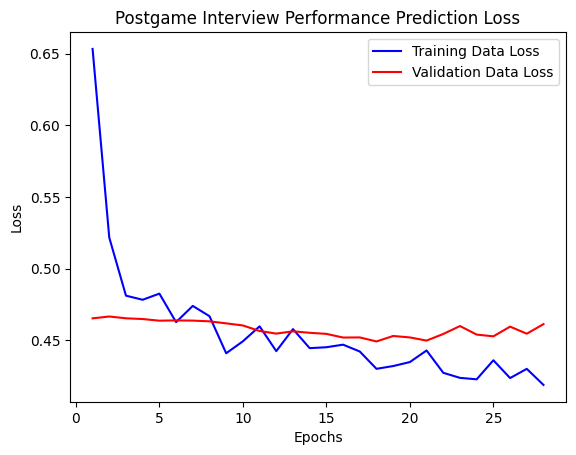

('E7eSerzOn9', 0.029386000000000002, 5e-06, 0.42870800000000003, 0.0007480000000000001, 0.37498, 0.05308500000000001, 0.113088, 0.29244288224956067, 1.0)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

data_file = 'emotion_results_final_with_gmsc.csv'
dtype = np.dtype([('id', 'U10'), ('avg_angry', float), ('avg_disgust', float), ('avg_fear', float), ('avg_happy', float), ('avg_sad', float), ('avg_surprise', float), ('avg_neutral', float), ('historical_gmsc_avg', float), ('next_game_gmsc', float )])
data = np.loadtxt(data_file, dtype=dtype, delimiter=',', skiprows=1, usecols=(2, 4, 5, 6, 7, 8, 9, 10, 13, 14))

# perform data normalization (scaling for emotions)
emotion_fields = [
    'avg_angry',
    'avg_disgust',
    'avg_fear',
    'avg_happy',
    'avg_sad',
    'avg_surprise',
    'avg_neutral',
]
for field in emotion_fields:
    data[field] = data[field] / 100.0

# split next_game_gmsc into 3 classes based on distribution:
# 0 if next_game_gmsc is less than 65% of historical_gmsc_avg
# 1 if next_game_gmsc is between 65% and 145% of historical_gmsc_avg
# 2 if next_game_gmsc is greater than 145% of historical_gmsc_avg
data['next_game_gmsc'] = np.where(
    data['next_game_gmsc'] < 0.65 * data['historical_gmsc_avg'], 0,
    np.where(
        data['next_game_gmsc'] > 1.45 * data['historical_gmsc_avg'], 2, 1
    )
)

data['historical_gmsc_avg'] = data['historical_gmsc_avg'] / np.max(data['historical_gmsc_avg'])

# write data to new csv file for testing
np.savetxt('test_data.csv', data, delimiter=',', fmt='%s', header=','.join(data.dtype.names), comments='')

# scramble data
np.random.shuffle(data)

# split data into training and testing sets
train_data = data[:int(len(data)*0.8)]
test_data = data[int(len(data)*0.8):]

# split data into features and labels
feature_names = data.dtype.names[1:-1]
x_train = np.array([train_data[name] for name in feature_names]).T
y_train = np.array(train_data['next_game_gmsc'])
x_test = np.array([test_data[name] for name in feature_names]).T
y_test = np.array(test_data['next_game_gmsc'])

# Store integer labels for class weight computation before one-hot encoding
y_train_int = y_train.copy()
y_test_int = y_test.copy()

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 3)
y_test = tf.keras.utils.to_categorical(y_test, 3)

# Check class distribution BEFORE splitting train/test
unique, counts = np.unique(data['next_game_gmsc'].astype(int), return_counts=True)
print("Class distribution in full dataset:")
for cls, count in zip(unique, counts):
    print(f"  Class {int(cls)}: {count} samples ({100*count/len(data):.1f}%)")

# Also check your threshold boundaries
print(f"\nClass 0 threshold: < {0.65:.2f}x historical avg")
print(f"Class 1 threshold: {0.65:.2f}x - {1.45:.2f}x historical avg")
print(f"Class 2 threshold: > {1.45:.2f}x historical avg")

model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

class_weights = [1.4, 0.6, 1.5]

print("Computed class weights:")
for i, w in enumerate(class_weights):
    print(f"  Class {i}: {w:.4f}")

def make_weighted_focal_loss(class_weights, gamma=2.0):
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)

    def weighted_focal_loss(y_true, y_pred):
        # y_true is already one-hot encoded
        y_true_one_hot = tf.cast(y_true, tf.float32)

        # Prevent log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross-entropy on probabilities
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)

        # Probability assigned to the true class
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)

        # Weight for the true class
        alpha_t = tf.reduce_sum(y_true_one_hot * class_weights_tensor, axis=-1)

        focal = alpha_t * tf.pow(1.0 - p_t, gamma) * ce
        return tf.reduce_mean(focal)

    return weighted_focal_loss

loss_fn = make_weighted_focal_loss(class_weights, gamma=2.0)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_fn,
    metrics=['accuracy']
)

model_history = model.fit(
    x_train, 
    y_train,
    epochs=100,
    batch_size=16,
    validation_data=(x_test, y_test),
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

# Print model loss graph
loss = model_history.history["loss"]
val_loss = model_history.history["val_loss"]
actual_epochs = range(1, len(loss) + 1)

# Use the new actual_epochs variable for the x-axis
plt.plot(actual_epochs, loss, "b-", label="Training Data Loss")
plt.plot(actual_epochs, val_loss, "r-", label="Validation Data Loss")

plt.title("Postgame Interview Performance Prediction Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

print(data[0])

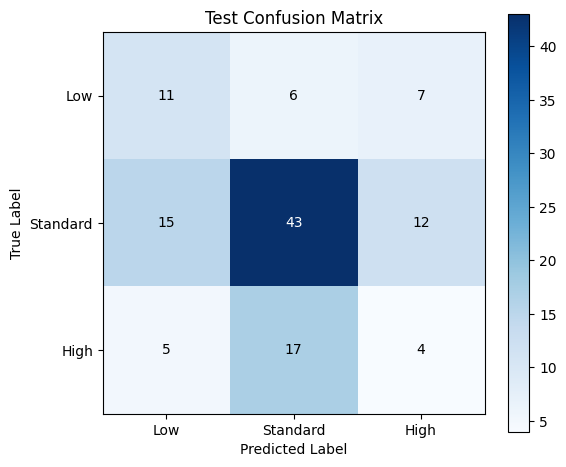

In [11]:
import tensorflow as tf

test_probs = model.predict(x_test, verbose=0)
test_pred = np.argmax(test_probs, axis=1)
test_true = np.argmax(y_test, axis=1)  # Convert one-hot back to class indices

cm = tf.math.confusion_matrix(test_true, test_pred, num_classes=3).numpy()
class_labels = ['Low', 'Standard', 'High']

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Test Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels)
plt.yticks(tick_marks, class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], 'd'),
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
        )

plt.tight_layout()
plt.show()